# Acoustic Drone Detection Using Deep Learning
### Exploring AI-Powered Civil Defense in High-Threat Environments

**Author: Abel Chuchu | UAE | March 2026**

---

## Motivation

The current military tension in the Middle East sparked my interest to explore ways I could apply machine learning for real-world scenarios. I have learned that military drones, such as Shahed suicide drones, are much more difficult to detect than larger threats like cruise missiles or the ballistic missiles recently launched by Iran.

These drones are difficult to detect because they have a small radar cross-section, fly at very low altitudes to stay under the radar horizon, and can easily be mistaken for birds or small aircraft on traditional sensors. However, I have noticed they have **distinctive acoustic fingerprints** often described as sounding like a "moped" or "lawnmower". This inspired me to train a model that would clearly identify military drones, which can assist in military defense for the UAE and Gulf countries.

Currently, there is no public dataset available that includes audio sounds of military drones, such as those currently being used by Iran like the **Shahed-131, Shahed-136, and Shahed-129**, or by the USA like the **LUCAS drone**.

Hence, I used the **largest drone audio database** I could find online (DADS) to train a model that can distinguish drone sounds from non-drone sounds, including urban noises like car revs, sirens, and wind. Since this dataset lacks military-specific audio and training on the full 6.6 GB of data is computationally intensive, I have developed this as a **proof of concept** using a representative sample. The model currently identifies drones such as electric quadcopters and various commercial electric drones.

---

## What This Notebook Does

1. Loads real drone audio data from HuggingFace
2. Converts audio into visual spectrograms the model can learn from
3. Trains a CNN to classify: **Drone vs. No Drone**
4. Evaluates the model on unseen test data
5. Runs an interactive demo where any audio file can be uploaded for classification
6. Demonstrates where the model falls short and explains why that gap matters

---

## Important Limitations

The dataset contains mostly **commercial electric drones** (quadcopters). Military drones like the **Shahed-136** use piston engines with a completely different sound signature not included in the dataset. This is currently a **proof of concept**, not a deployable defense system. With enough data and improvements, similar systems could help support organizations or public safety agencies in monitoring airspace. For example, the model could analyze live audio from microphones or sound sensors and detect drones in real time. It could also be extended to multiclass classification to identify different types of drones or other flying objects.

---

## Dataset

**DADS: Drone Audio Detection Samples** (HuggingFace)   
**[Dataset Link](https://huggingface.co/datasets/geronimobasso/drone-audio-detection-samples)**

Standardized WAV files at 16,000 Hz, mono channel. Label 0 = No Drone. Label 1 = Drone. Includes urban background noise such as sirens, traffic, and wind.

---

## System Pipeline

```
Audio Input
   |
   v
Audio Preprocessing
   |
   v
Feature Extraction (Mel Spectrogram)
   |
   v
Deep Learning Model (CNN)
   |
   v
Binary Classification (Drone / No Drone)
   |
   v
Evaluation Metrics
   |
   v
Prediction Interface and Demo
```

**Tools and Libraries:** Python, Google Colab, PyTorch, Librosa, NumPy, Matplotlib, Scikit-learn, Seaborn, Gradio

**Hardware:** A Colab GPU (T4) is recommended. Navigate to Runtime > Change Runtime Type > T4 GPU before running.

---
## Section 1: Environment Setup

This section installs all required libraries and imports them into the session. Random seeds are fixed across Python, NumPy, and PyTorch to ensure that results are reproducible across runs. The available compute device is then detected so the model can take advantage of GPU acceleration if it is available.

In [ ]:
# Install all required packages for this project.
!pip install -q datasets librosa torchaudio gradio scikit-learn seaborn tqdm soundfile

In [ ]:
# Standard library imports.
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Numerical and visualization libraries.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Audio processing libraries.
import librosa
import librosa.display
import torchaudio
import soundfile as sf
from IPython.display import Audio, display

# PyTorch core libraries.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# HuggingFace datasets library.
from datasets import load_dataset

# Evaluation and data splitting utilities.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split

print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
# Fix random seeds across Python, NumPy, and PyTorch to ensure reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Detect whether a GPU is available and set the compute device accordingly.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Compute device: {device}')
if device.type == 'cuda':
    print(f'GPU detected: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU detected. Navigate to Runtime > Change Runtime Type > T4 GPU for faster training.')

Compute device: cuda
GPU detected: Tesla T4


---
## Section 2: Data Loading

The DADS dataset is loaded directly from HuggingFace using a single function call. Because the full dataset is approximately 6.6 GB, a representative subset of 6,000 samples is selected to remain within Colab memory constraints. The class distribution of this subset is then inspected to confirm the balance between drone and non-drone samples.

In [ ]:
# Load the DADS dataset from HuggingFace.
# DADS is the largest publicly available drone audio database,
# standardized to 16,000 Hz mono WAV format with binary class labels.
print('Loading DADS dataset from HuggingFace...')
print('This may take a few minutes on the first run.')

raw_dataset = load_dataset(
    'geronimobasso/drone-audio-detection-samples',
    split='train'
)

print(f'Dataset loaded successfully.')
print(f'Total samples available: {len(raw_dataset):,}')

Loading DADS dataset from HuggingFace...
This may take a few minutes on the first run.


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

data/train-00000-of-00039.parquet:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

Dataset loaded successfully.
Total samples available: 180,320


In [ ]:
# Inspect the structure of the dataset to understand its fields and format
# before any processing begins.
print('Dataset structure:')
print(raw_dataset)
print()
print('Fields in a single sample:', list(raw_dataset[0].keys()))
print()
sample = raw_dataset[0]
for key, val in sample.items():
    if key != 'audio':
        print(f'  {key}: {val}')
audio_arr = np.array(sample['audio']['array'])
print(f'  audio: array shape {audio_arr.shape}, sample_rate={sample["audio"]["sampling_rate"]}')

Dataset structure:
Dataset({
    features: ['audio', 'label'],
    num_rows: 180320
})

Fields in a single sample: ['audio', 'label']

  label: 0
  audio: array shape (5081,), sample_rate=16000


Subset summary:
  Total samples : 6,000
  Drone     (1) : 5,470  (91.2%)
  No Drone  (0) : 530  (8.8%)


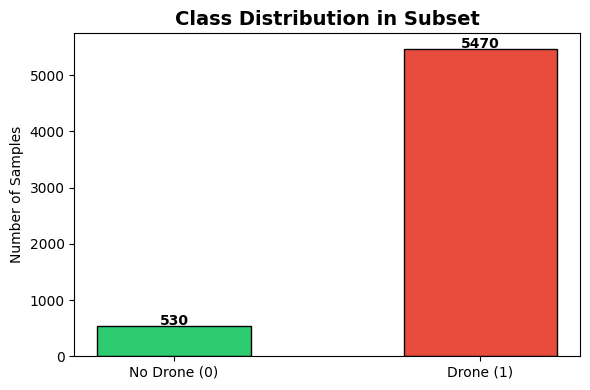

In [ ]:
# Select a random subset of 6,000 samples from the full dataset.
# This keeps memory usage within Colab limits while providing sufficient
# data for a meaningful training run. Increase SUBSET_SIZE if more
# memory and compute time are available.
SUBSET_SIZE = 6000

indices = list(range(len(raw_dataset)))
random.shuffle(indices)
subset_indices = indices[:SUBSET_SIZE]
dataset_subset = raw_dataset.select(subset_indices)

# Count and display the class distribution within the selected subset.
labels         = [dataset_subset[i]['label'] for i in range(len(dataset_subset))]
drone_count    = labels.count(1)
no_drone_count = labels.count(0)

print('Subset summary:')
print(f'  Total samples : {len(dataset_subset):,}')
print(f'  Drone     (1) : {drone_count:,}  ({drone_count/len(dataset_subset)*100:.1f}%)')
print(f'  No Drone  (0) : {no_drone_count:,}  ({no_drone_count/len(dataset_subset)*100:.1f}%)')

# Visualize the class balance as a bar chart.
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['No Drone (0)', 'Drone (1)'],
    [no_drone_count, drone_count],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
ax.set_title('Class Distribution in Subset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples')
for bar, count in zip(bars, [no_drone_count, drone_count]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3: Audio Exploration and Visualization

Before training any model, it is important to understand what the data looks and sounds like. This section produces four visualizations: raw waveforms, Mel-Spectrograms, MFCC features, and a spectrogram comparison grid. The central concept is that audio is converted into a two-dimensional image called a Mel-Spectrogram, which the CNN then learns to classify. The visual difference between drone and non-drone spectrograms is apparent even before any training takes place, which gives confidence that the classification problem is tractable.

In [ ]:
# Retrieve one representative audio sample for each class from the subset.
# These samples are reused across all visualization cells in this section.
def get_sample_by_label(dataset, label):
    """Return the first audio array and sample rate that matches the given label."""
    for i in range(len(dataset)):
        if dataset[i]['label'] == label:
            audio_array = np.array(dataset[i]['audio']['array'], dtype=np.float32)
            sr = dataset[i]['audio']['sampling_rate']
            return audio_array, sr
    return None, None

drone_audio,   sr = get_sample_by_label(dataset_subset, 1)
nodrone_audio, sr = get_sample_by_label(dataset_subset, 0)

print(f'Sample rate: {sr} Hz')
print(f'Drone audio duration   : {len(drone_audio)/sr:.2f} seconds')
print(f'No-drone audio duration: {len(nodrone_audio)/sr:.2f} seconds')

Sample rate: 16000 Hz
Drone audio duration   : 0.50 seconds
No-drone audio duration: 0.98 seconds


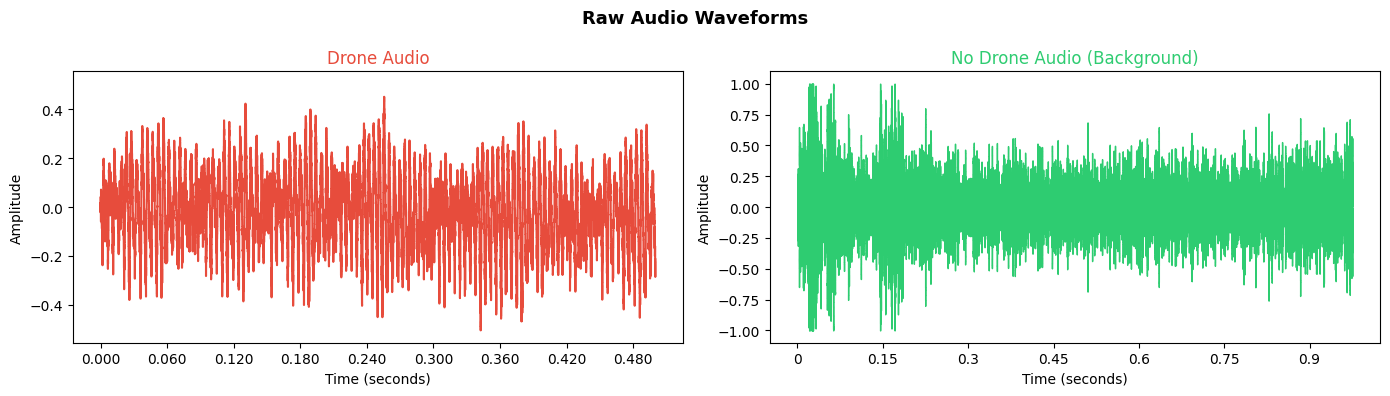

In [ ]:
# Visualization 1: Raw waveforms.
# A waveform plots amplitude over time. Drone audio produced by spinning
# propellers tends to exhibit a more regular, repeating amplitude pattern
# compared to the unstructured character of background noise.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Raw Audio Waveforms', fontsize=13, fontweight='bold')

librosa.display.waveshow(drone_audio, sr=sr, ax=axes[0], color='#e74c3c')
axes[0].set_title('Drone Audio', fontsize=12, color='#e74c3c')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')

librosa.display.waveshow(nodrone_audio, sr=sr, ax=axes[1], color='#2ecc71')
axes[1].set_title('No Drone Audio (Background)', fontsize=12, color='#2ecc71')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

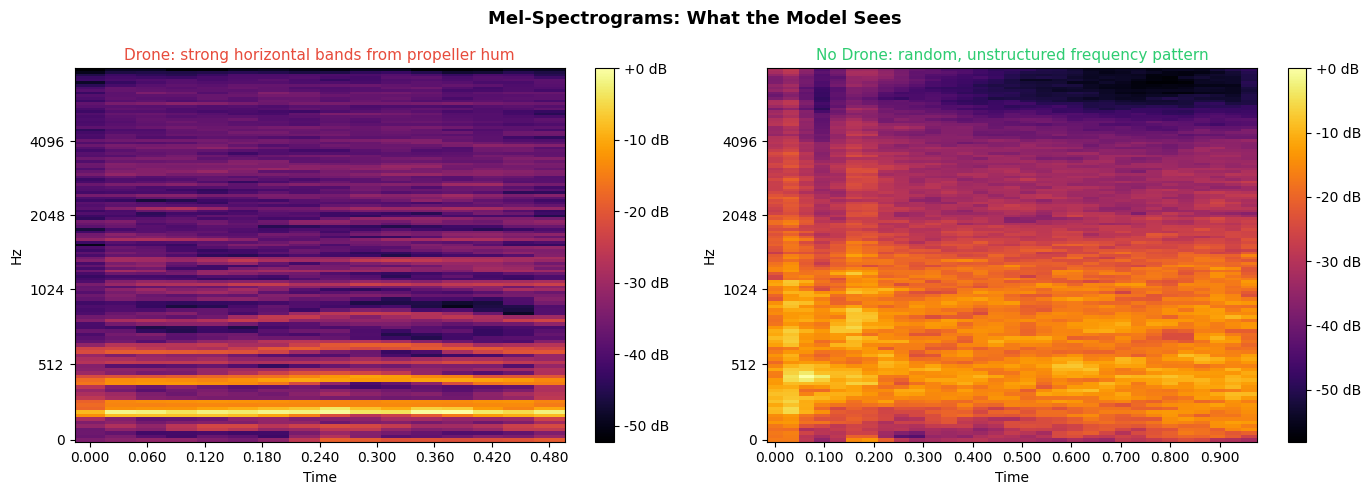

In [ ]:
# Visualization 2: Mel-Spectrograms.
# A Mel-Spectrogram represents audio as a 2D image where the x-axis is time,
# the y-axis is frequency on the mel scale, and color encodes intensity in decibels.
# This is the exact representation passed to the CNN during training.
# Drone audio typically shows strong horizontal frequency bands from propeller harmonics,
# while background noise produces a more scattered and unstructured pattern.

def compute_mel_spectrogram(audio, sr=16000, n_mels=128):
    """Convert a raw audio array to a decibel-scaled Mel-Spectrogram."""
    mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

drone_mel   = compute_mel_spectrogram(drone_audio)
nodrone_mel = compute_mel_spectrogram(nodrone_audio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mel-Spectrograms: What the Model Sees', fontsize=13, fontweight='bold')

img1 = librosa.display.specshow(drone_mel, sr=sr, x_axis='time',
                                  y_axis='mel', ax=axes[0], cmap='inferno')
axes[0].set_title('Drone: strong horizontal bands from propeller hum',
                   fontsize=11, color='#e74c3c')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

img2 = librosa.display.specshow(nodrone_mel, sr=sr, x_axis='time',
                                  y_axis='mel', ax=axes[1], cmap='inferno')
axes[1].set_title('No Drone: random, unstructured frequency pattern',
                   fontsize=11, color='#2ecc71')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

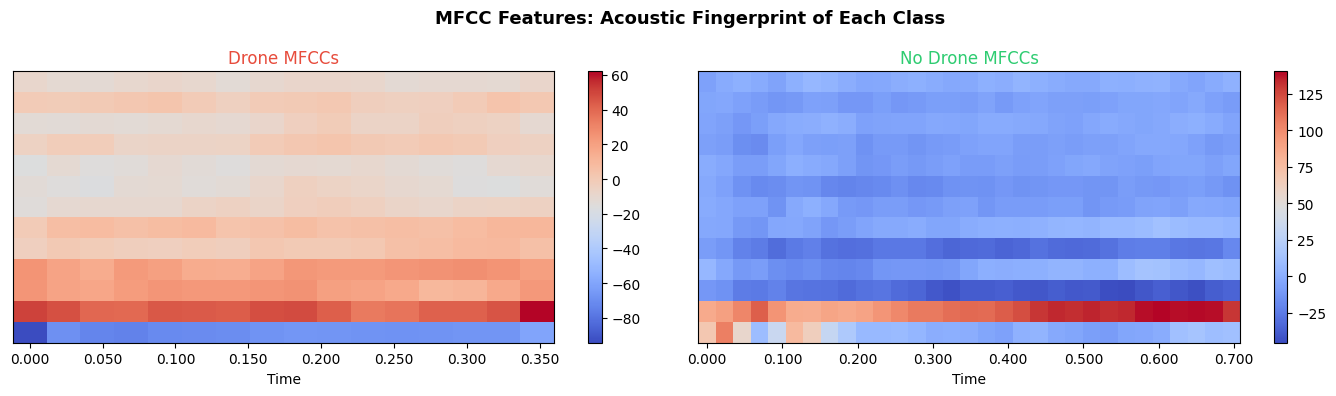

In [ ]:
# Visualization 3: MFCC features.
# Mel-Frequency Cepstral Coefficients (MFCCs) capture the timbral texture of a sound.
# They act as a compact acoustic fingerprint and reveal class-level differences
# that are not always apparent from the raw waveform alone.

drone_mfcc   = librosa.feature.mfcc(y=drone_audio,   sr=sr, n_mfcc=13)
nodrone_mfcc = librosa.feature.mfcc(y=nodrone_audio, sr=sr, n_mfcc=13)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('MFCC Features: Acoustic Fingerprint of Each Class',
             fontsize=13, fontweight='bold')

img1 = librosa.display.specshow(drone_mfcc,   x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_title('Drone MFCCs',    color='#e74c3c')
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(nodrone_mfcc, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_title('No Drone MFCCs', color='#2ecc71')
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# Play the audio samples inline to hear the acoustic difference directly.
print('Drone audio sample:')
display(Audio(drone_audio, rate=sr))

print()
print('No drone audio sample (background noise):')
display(Audio(nodrone_audio, rate=sr))

Drone audio sample:



No drone audio sample (background noise):


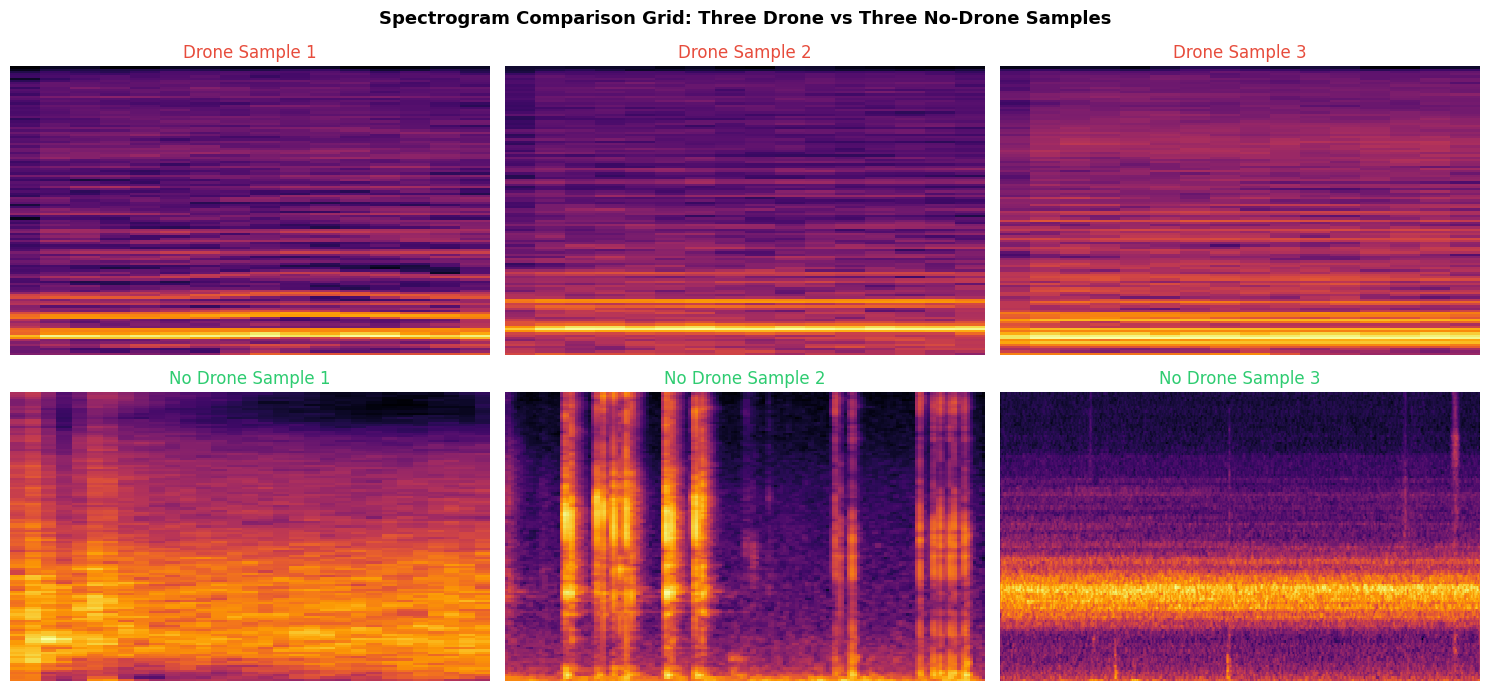

In [ ]:
# Visualization 4: Spectrogram comparison grid.
# Displaying three samples per class confirms that the visual pattern is
# consistent across different recordings and not an artifact of a single example.
# This gives confidence that the CNN can learn a generalizable pattern.

drone_samples   = []
nodrone_samples = []

for i in range(len(dataset_subset)):
    if len(drone_samples) >= 3 and len(nodrone_samples) >= 3:
        break
    audio = np.array(dataset_subset[i]['audio']['array'], dtype=np.float32)
    label = dataset_subset[i]['label']
    if label == 1 and len(drone_samples) < 3:
        drone_samples.append(audio)
    elif label == 0 and len(nodrone_samples) < 3:
        nodrone_samples.append(audio)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Spectrogram Comparison Grid: Three Drone vs Three No-Drone Samples',
             fontsize=13, fontweight='bold')

for i, audio in enumerate(drone_samples):
    mel = compute_mel_spectrogram(audio)
    librosa.display.specshow(mel, sr=sr, ax=axes[0][i], cmap='inferno')
    axes[0][i].set_title(f'Drone Sample {i+1}', color='#e74c3c')
    axes[0][i].axis('off')

for i, audio in enumerate(nodrone_samples):
    mel = compute_mel_spectrogram(audio)
    librosa.display.specshow(mel, sr=sr, ax=axes[1][i], cmap='inferno')
    axes[1][i].set_title(f'No Drone Sample {i+1}', color='#2ecc71')
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

---
## Section 4: Global Configuration

All key parameters that govern audio processing and model behaviour are defined here in a single location. Changing any value in this cell will propagate consistently through the rest of the notebook.

In [ ]:
# Central configuration for all audio processing and model training steps.
# Adjusting these values here will apply them throughout the notebook.
SAMPLE_RATE = 16000   # Target sample rate in Hz. Already standardized in DADS.
DURATION    = 2       # Duration in seconds extracted from each audio clip.
N_MELS      = 128     # Number of mel frequency bands in the spectrogram.
IMG_SIZE    = 128     # Final spectrogram image resolution in pixels.
NUM_SAMPLES = SAMPLE_RATE * DURATION  # Total audio samples per clip.

print('Configuration:')
print(f'  Sample rate : {SAMPLE_RATE} Hz')
print(f'  Clip length : {DURATION} seconds ({NUM_SAMPLES:,} samples)')
print(f'  Mel bands   : {N_MELS}')
print(f'  Image size  : {IMG_SIZE} x {IMG_SIZE} pixels')

Configuration:
  Sample rate : 16000 Hz
  Clip length : 2 seconds (32,000 samples)
  Mel bands   : 128
  Image size  : 128 x 128 pixels


---
## Section 5: Preprocessing Pipeline

Each raw audio clip must be converted into a fixed-size tensor before it can be passed to the CNN. The preprocessing function below handles every step of this transformation: padding or trimming to a consistent length, computing the Mel-Spectrogram, applying a colour map to produce an RGB image, resizing to 128x128 pixels, normalising pixel values, and converting to a PyTorch tensor. A before-and-after visualisation confirms that the transformation produces a clean, model-ready input.

```
Raw Audio (.wav)
      |
      v
Resample to 16,000 Hz (already standardized in DADS)
      |
      v
Pad or trim to fixed length (2 seconds)
      |
      v
Extract Mel-Spectrogram (128 mel bands)
      |
      v
Convert to decibels and apply inferno colour map
      |
      v
Resize to 128x128 pixels
      |
      v
Normalize pixel values to [0, 1]
      |
      v
Convert to PyTorch Tensor (shape: 3 x 128 x 128)
      |
      v
Ready for Model
```

In [ ]:
# Core preprocessing function that converts a raw audio array into a
# normalised RGB spectrogram tensor suitable for input to the CNN.
# Every sample in the dataset is passed through this function before
# being seen by the model.

def preprocess_audio(audio_array, sr=SAMPLE_RATE):
    """
    Convert a raw audio array to a normalised Mel-Spectrogram tensor.

    Steps:
      1. Cast to float32 and pad or trim to a fixed duration.
      2. Compute Mel-Spectrogram and convert to decibels.
      3. Apply the inferno colour map to produce a three-channel RGB image.
      4. Resize to IMG_SIZE x IMG_SIZE.
      5. Normalise pixel values to [0, 1].
      6. Return as a PyTorch tensor of shape (3, H, W).
    """
    from PIL import Image

    audio = np.array(audio_array, dtype=np.float32)

    # Pad with zeros if shorter than the target length; trim if longer.
    if len(audio) < NUM_SAMPLES:
        audio = np.pad(audio, (0, NUM_SAMPLES - len(audio)))
    else:
        audio = audio[:NUM_SAMPLES]

    # Compute the Mel-Spectrogram and scale to decibels.
    mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Apply the inferno colour map to produce a three-channel representation.
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    mel_rgb  = plt.cm.inferno(mel_norm)[:, :, :3]  # Drop the alpha channel.

    # Resize to the target image dimensions and normalise pixel values to [0, 1].
    img       = Image.fromarray((mel_rgb * 255).astype(np.uint8))
    img       = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img, dtype=np.float32) / 255.0

    # Convert from (H, W, C) to (C, H, W) as required by PyTorch.
    tensor = torch.tensor(img_array).permute(2, 0, 1)

    return tensor


# Verify that the function produces the expected output shape.
test_tensor = preprocess_audio(drone_audio)
print('Preprocessing verified.')
print(f'  Input  : audio array of {len(drone_audio):,} samples')
print(f'  Output : tensor of shape {test_tensor.shape}  (channels, height, width)')

Preprocessing verified.
  Input  : audio array of 8,000 samples
  Output : tensor of shape torch.Size([3, 128, 128])  (channels, height, width)


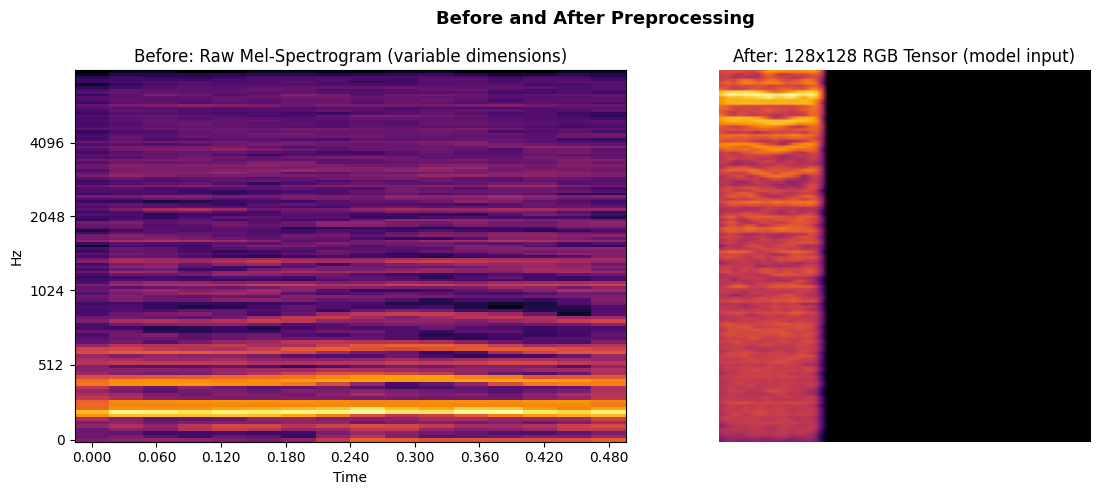

In [ ]:
# Visualize the raw Mel-Spectrogram alongside the preprocessed tensor
# to confirm that the pipeline produces a clean, model-ready input image.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Before and After Preprocessing', fontsize=13, fontweight='bold')

raw_mel = compute_mel_spectrogram(drone_audio)
librosa.display.specshow(raw_mel, sr=sr, x_axis='time', y_axis='mel',
                          ax=axes[0], cmap='inferno')
axes[0].set_title('Before: Raw Mel-Spectrogram (variable dimensions)')

processed = preprocess_audio(drone_audio).permute(1, 2, 0).numpy()
axes[1].imshow(processed)
axes[1].set_title(f'After: {IMG_SIZE}x{IMG_SIZE} RGB Tensor (model input)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Section 6: Dataset Splitting and DataLoaders

The subset is divided into training, validation, and test sets following a 70/15/15 split. A custom PyTorch Dataset class wraps the HuggingFace data and applies the preprocessing function on the fly during iteration. DataLoaders are then created for each split to deliver batches to the model efficiently during training and evaluation.

In [ ]:
# Custom PyTorch Dataset class that wraps the HuggingFace dataset.
# The __getitem__ method retrieves a single sample, applies preprocessing,
# and returns a (tensor, label) pair ready for the DataLoader.

class DroneAudioDataset(Dataset):
    def __init__(self, hf_dataset, indices):
        """
        Parameters
        ----------
        hf_dataset : HuggingFace Dataset object
        indices    : list of integer indices indicating which samples belong to this split
        """
        self.dataset = hf_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        sample   = self.dataset[real_idx]
        audio    = sample['audio']['array']
        label    = sample['label']
        tensor   = preprocess_audio(audio)
        return tensor, torch.tensor(label, dtype=torch.long)

print('DroneAudioDataset class defined.')

DroneAudioDataset class defined.


In [ ]:
# Split the dataset indices into training, validation, and test sets
# following a 70 / 15 / 15 ratio.
all_indices = list(range(len(dataset_subset)))

train_val_idx, test_idx = train_test_split(
    all_indices, test_size=0.15, random_state=SEED
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.176, random_state=SEED
)

print('Dataset split:')
print(f'  Training   : {len(train_idx):,} samples ({len(train_idx)/len(all_indices)*100:.0f}%)')
print(f'  Validation : {len(val_idx):,} samples ({len(val_idx)/len(all_indices)*100:.0f}%)')
print(f'  Test       : {len(test_idx):,} samples ({len(test_idx)/len(all_indices)*100:.0f}%)')

# Instantiate Dataset objects and DataLoaders for each split.
train_dataset = DroneAudioDataset(dataset_subset, train_idx)
val_dataset   = DroneAudioDataset(dataset_subset, val_idx)
test_dataset  = DroneAudioDataset(dataset_subset, test_idx)

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'DataLoaders ready. Batch size: {BATCH_SIZE}')

Dataset split:
  Training   : 4,202 samples (70%)
  Validation : 898 samples (15%)
  Test       : 900 samples (15%)
DataLoaders ready. Batch size: 32


---
## Section 7: Model Architecture

The model is a custom Convolutional Neural Network (CNN) that takes a 128x128 RGB spectrogram image as input and outputs a probability score for each class. The architecture consists of three convolutional blocks for feature extraction followed by two fully connected layers for classification. Batch normalisation is applied after each convolution to stabilise training, and dropout is used in the classifier head to reduce overfitting. Changing `num_classes` from 2 to any larger number extends this architecture directly to multiclass detection, for example distinguishing quadcopters, helicopters, fixed-wing UAVs, and military drones.

```
Input (3 x 128 x 128 Mel-Spectrogram)
      |
      v
Conv2D (32 filters) + BatchNorm + ReLU + MaxPool  -->  (32 x 64 x 64)
      |
      v
Conv2D (64 filters) + BatchNorm + ReLU + MaxPool  -->  (64 x 32 x 32)
      |
      v
Conv2D (128 filters) + BatchNorm + ReLU + MaxPool -->  (128 x 16 x 16)
      |
      v
Flatten
      |
      v
Fully Connected (256 units) + ReLU + Dropout (0.3)
      |
      v
Fully Connected (64 units) + ReLU
      |
      v
Output (2 classes: Drone / No Drone)
      |
      v
Softmax -> Probability Score
```

In [ ]:
# CNN model definition.
# Three convolutional blocks progressively extract spatial features from the spectrogram.
# Two fully connected layers map those features to a binary class prediction.
# Setting num_classes to a larger value extends this to multiclass detection.

class DroneCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(DroneCNN, self).__init__()

        # Feature extractor: three convolutional blocks.
        # Each block applies convolution, batch normalisation, ReLU activation,
        # and max pooling to halve the spatial dimensions.
        self.features = nn.Sequential(
            # Block 1: (3, 128, 128) to (32, 64, 64)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: (32, 64, 64) to (64, 32, 32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: (64, 32, 32) to (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Classifier: two fully connected layers with dropout regularisation.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instantiate the model and move it to the selected compute device.
model = DroneCNN(num_classes=2).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

DroneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropou

---
## Section 8: Training

The model is trained using cross-entropy loss and the Adam optimiser. A learning rate scheduler reduces the learning rate automatically when validation loss plateaus. Early stopping halts training if no improvement is observed for five consecutive epochs to prevent wasted compute time. The best model checkpoint is saved to disk throughout training so that the version with the lowest validation loss is always preserved regardless of when training terminates.

In [ ]:
# Define training hyperparameters and all optimisation components.
EPOCHS   = 20     # Maximum number of training epochs.
LR       = 0.001  # Initial learning rate for the Adam optimiser.
PATIENCE = 5      # Epochs without improvement before early stopping is triggered.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
)

print('Training configuration:')
print(f'  Max epochs   : {EPOCHS}')
print(f'  Learning rate: {LR}')
print(f'  Optimiser    : Adam')
print(f'  Early stop   : {PATIENCE} epochs patience')

Training configuration:
  Max epochs   : 20
  Learning rate: 0.001
  Optimiser    : Adam
  Early stop   : 5 epochs patience


In [ ]:
# Training and evaluation helper functions.
# Separating these from the main loop keeps the training cell readable
# and makes each function independently testable.

def train_one_epoch(model, loader, criterion, optimizer):
    """Run one complete pass over the training data and return average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate the model on a given loader and return average loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = model(inputs)
            loss           = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total

print('Training and evaluation functions defined.')

Training and evaluation functions defined.


In [ ]:
# Main training loop.
# Loss and accuracy are logged at each epoch. The checkpoint with the lowest
# validation loss is saved to disk. Training halts automatically if no improvement
# is observed for PATIENCE consecutive epochs.

history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = 'best_drone_model.pth'

print(f'Starting training on {device}...')
print('=' * 65)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>6.2%}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'         Best model checkpoint saved (val_loss={best_val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch}. No improvement for {PATIENCE} consecutive epochs.')
            break

print('=' * 65)
print(f'Training complete. Best validation loss: {best_val_loss:.4f}')

Starting training on cuda...
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
     1 |     0.1311 |   98.48% |   0.0327 | 99.67%
         Best model checkpoint saved (val_loss=0.0327)
     2 |     0.0281 |   99.55% |   0.0233 | 99.78%
         Best model checkpoint saved (val_loss=0.0233)
     3 |     0.0131 |   99.74% |   0.0175 | 99.78%
         Best model checkpoint saved (val_loss=0.0175)
     4 |     0.0104 |   99.79% |   0.0177 | 99.44%
     5 |     0.0120 |   99.69% |   0.0256 | 99.78%
     6 |     0.0137 |   99.60% |   0.0222 | 99.89%
     7 |     0.0090 |   99.76% |   0.0188 | 99.89%
     8 |     0.0073 |   99.79% |   0.0167 | 99.89%
         Best model checkpoint saved (val_loss=0.0167)
     9 |     0.0040 |   99.83% |   0.0208 | 99.89%
    10 |     0.0038 |   99.86% |   0.0246 | 99.89%
    11 |     0.0031 |   99.88% |   0.0256 | 99.89%
    12 |     0.0014 |   99.93% |   0.0304 | 99.89%
    13 |     0.0022 |   99.93% |   0.0284 | 99.89%

Early stopping triggered at epoch 

---
## Section 9: Evaluation and Visualizations

The best saved checkpoint is loaded and evaluated on the held-out test set. This section produces a full classification report, a confusion matrix heatmap, an ROC curve with AUC score, and the training history curves. Together these metrics provide an objective assessment of model performance on data that was never seen during training.

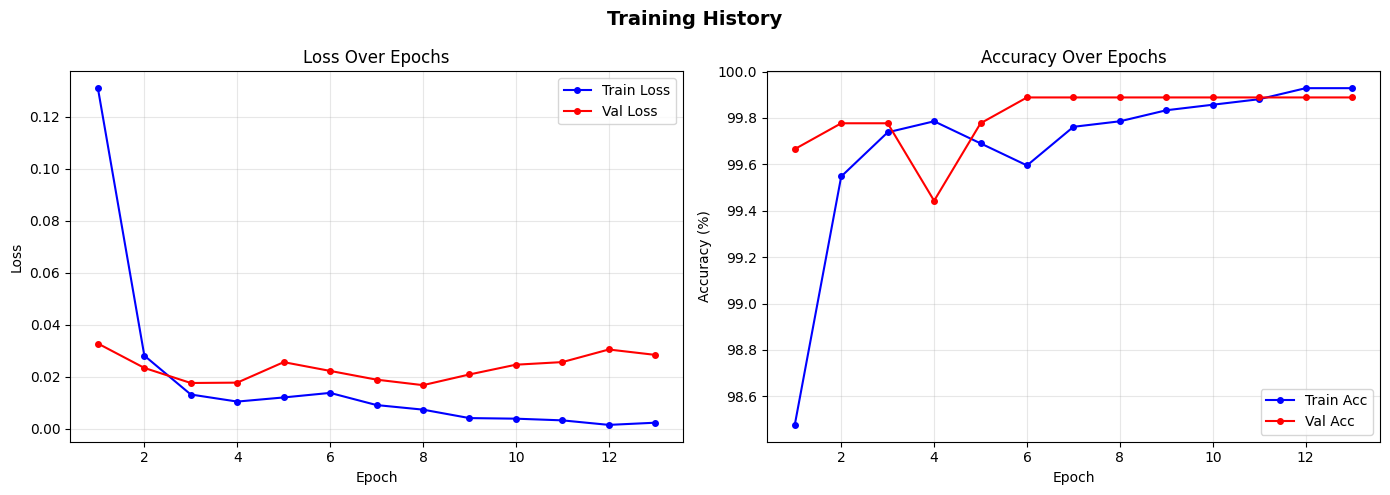

In [ ]:
# Plot the training and validation loss and accuracy curves.
# These curves reveal whether the model learned progressively and
# whether overfitting occurred at any point during training.

epochs_ran  = len(history['train_loss'])
epoch_range = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(epoch_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epoch_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_range, [a * 100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epoch_range, [a * 100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Load the best saved checkpoint and run inference across the full test set.
# Predictions, ground truth labels, and drone probability scores are collected
# across all batches for use in the evaluation plots below.

model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs  = inputs.to(device)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('Classification Report on Test Set:')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=['No Drone', 'Drone']))

Classification Report on Test Set:
              precision    recall  f1-score   support

    No Drone       0.99      1.00      0.99        92
       Drone       1.00      1.00      1.00       808

    accuracy                           1.00       900
   macro avg       0.99      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



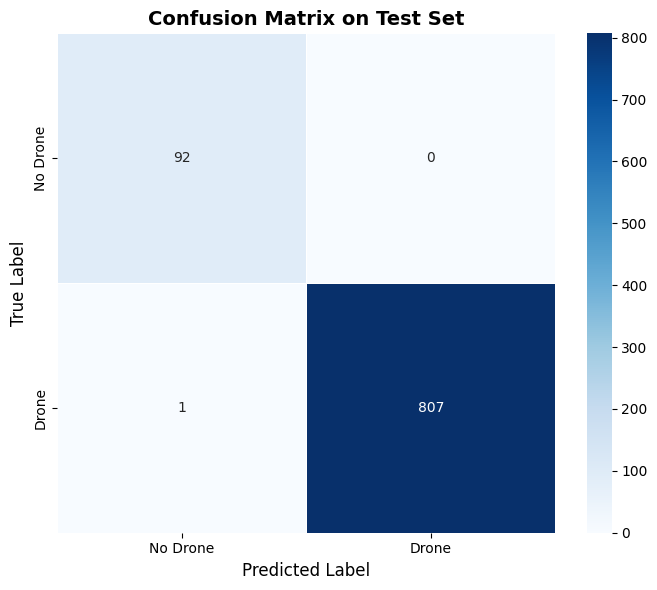

True Positives  (drone correctly detected)  : 807
True Negatives  (clear correctly identified): 92
False Positives (false alarm)               : 0
False Negatives (missed drone)              : 1


In [ ]:
# Confusion matrix showing the count of correct and incorrect predictions per class.
# In an operational defense context, false negatives represent missed drone detections
# and are the most consequential error type.

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Drone', 'Drone'],
            yticklabels=['No Drone', 'Drone'],
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (drone correctly detected)  : {tp}')
print(f'True Negatives  (clear correctly identified): {tn}')
print(f'False Positives (false alarm)               : {fp}')
print(f'False Negatives (missed drone)              : {fn}')

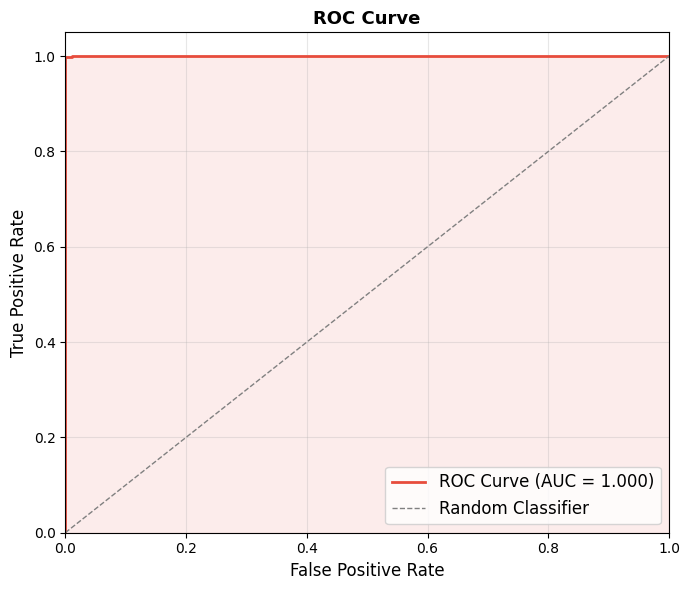

AUC Score: 1.000
The model demonstrates strong discriminative performance on this dataset.


In [ ]:
# ROC curve illustrating the tradeoff between the true positive rate and
# false positive rate across all classification thresholds.
# The AUC score summarises the overall discriminative ability of the model
# with a value of 1.0 representing perfect separation between classes.

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC Score: {roc_auc:.3f}')
if roc_auc > 0.9:
    print('The model demonstrates strong discriminative performance on this dataset.')
elif roc_auc > 0.75:
    print('Performance is reasonable. Additional data or tuning may improve results further.')
else:
    print('Performance is below expectation. Consider increasing dataset size or model capacity.')

---
## Section 10: Single File Inference

A reusable prediction function is defined here that accepts any raw audio array and returns the classification label along with a confidence score. The function is tested on five samples drawn from the test set to confirm that end-to-end inference is working as expected.

In [ ]:
# Inference function that accepts a raw audio array and returns the predicted
# class label and associated confidence score. This function is also called
# internally by the Gradio dashboard in the next section.

def predict(audio_array, sr=SAMPLE_RATE, threshold=0.5):
    """
    Classify an audio array as drone or no drone.

    Parameters
    ----------
    audio_array : numpy array of raw audio samples
    sr          : sample rate of the input audio
    threshold   : minimum drone probability required to trigger a positive prediction

    Returns
    -------
    label       : 'DRONE' or 'CLEAR'
    confidence  : probability of the predicted class
    drone_prob  : raw drone class probability from the softmax output
    """
    model.eval()
    tensor = preprocess_audio(audio_array).unsqueeze(0).to(device)

    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)
        drone_prob = probs[0][1].item()

    is_drone   = drone_prob >= threshold
    label      = 'DRONE' if is_drone else 'CLEAR'
    confidence = drone_prob if is_drone else (1 - drone_prob)

    return label, confidence, drone_prob


# Test the prediction function on five samples from the held-out test set.
print('Predictions on five test set samples:')
print('=' * 60)

for i in range(5):
    idx        = test_idx[i]
    sample     = dataset_subset[idx]
    audio      = np.array(sample['audio']['array'], dtype=np.float32)
    true_label = 'DRONE' if sample['label'] == 1 else 'NO DRONE'

    label, confidence, drone_prob = predict(audio)
    correct = (label == 'DRONE') == (sample['label'] == 1)
    status  = 'CORRECT' if correct else 'INCORRECT'

    print(f'Sample {i+1}: True={true_label:<9} | Predicted={label:<6} | Confidence={confidence:.1%} | {status}')

Predictions on five test set samples:
Sample 1: True=DRONE     | Predicted=DRONE  | Confidence=100.0% | CORRECT
Sample 2: True=DRONE     | Predicted=DRONE  | Confidence=100.0% | CORRECT
Sample 3: True=DRONE     | Predicted=DRONE  | Confidence=100.0% | CORRECT
Sample 4: True=DRONE     | Predicted=DRONE  | Confidence=100.0% | CORRECT
Sample 5: True=DRONE     | Predicted=DRONE  | Confidence=100.0% | CORRECT


---
## Section 11: Interactive Detection Dashboard

A Gradio interface is built here to allow interactive testing of the trained model. Any WAV audio file can be uploaded and classified in real time. The dashboard displays the waveform and Mel-Spectrogram of the uploaded audio alongside the prediction result and a drone probability slider. Two example buttons load pre-saved samples directly, making it easy to demonstrate the model without sourcing external files. This section is the primary screen-recording target for social media demonstration.

In [ ]:
import gradio as gr
import matplotlib
import io
from PIL import Image as PILImage
matplotlib.use('Agg')

# Save one drone and one no-drone example as WAV files for the dashboard buttons.
example_drone_path   = '/tmp/example_drone.wav'
example_nodrone_path = '/tmp/example_nodrone.wav'

for i in range(len(dataset_subset)):
    s = dataset_subset[i]
    a = np.array(s['audio']['array'], dtype=np.float32)
    if s['label'] == 1:
        sf.write(example_drone_path, a, sr)
        break

for i in range(len(dataset_subset)):
    s = dataset_subset[i]
    a = np.array(s['audio']['array'], dtype=np.float32)
    if s['label'] == 0:
        sf.write(example_nodrone_path, a, sr)
        break

print('Example audio files saved.')


def run_detection(audio_input):
    """
    Core callback function for the Gradio interface.
    Accepts an audio input, runs the prediction pipeline, and returns
    a spectrogram image, a result string, and the drone probability score.
    """
    if audio_input is None:
        return None, 'Upload an audio file above to begin.', 0.0

    try:
        if isinstance(audio_input, tuple):
            input_sr, audio_array = audio_input
            audio_array = audio_array.astype(np.float32)
            if audio_array.max() > 1.0:
                audio_array = audio_array / 32768.0
            if len(audio_array.shape) > 1:
                audio_array = audio_array.mean(axis=1)
        else:
            audio_array, input_sr = librosa.load(audio_input, sr=SAMPLE_RATE, mono=True)
    except Exception as e:
        return None, f'Error loading audio: {str(e)}', 0.0

    label, confidence, drone_prob = predict(audio_array)
    color = '#e74c3c' if label == 'DRONE' else '#2ecc71'

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    librosa.display.waveshow(audio_array[:SAMPLE_RATE * 2], sr=SAMPLE_RATE,
                              ax=axes[0], color=color)
    axes[0].set_title('Audio Waveform', fontsize=12)
    axes[0].set_xlabel('Time (s)')

    mel    = librosa.feature.melspectrogram(
        y=audio_array[:SAMPLE_RATE * 2], sr=SAMPLE_RATE, n_mels=128
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=SAMPLE_RATE, x_axis='time',
                                       y_axis='mel', ax=axes[1], cmap='inferno')
    axes[1].set_title('Mel-Spectrogram (model input)', fontsize=12)
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    buf = io.BytesIO()
    plt.tight_layout()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    spec_image = PILImage.open(buf)

    if label == 'DRONE':
        result_text = f'THREAT DETECTED\n\nDrone probability: {drone_prob:.1%}\nConfidence: {confidence:.1%}'
    else:
        result_text = f'AREA CLEAR\n\nDrone probability: {drone_prob:.1%}\nConfidence: {confidence:.1%}'

    return spec_image, result_text, float(drone_prob)


# Build the Gradio interface.
with gr.Blocks(theme=gr.themes.Base(), title='Drone Detection System') as demo:

    gr.Markdown("""
    # 🛡️ Acoustic Drone Detection System
    ### UAE Civil Defense — Proof of Concept
    **Author: Abel Chuchu**

    Upload a WAV audio file or use the example buttons below.
    The model will classify it as Drone or No Drone in real time.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(
                label='Upload Audio File (.wav)',
                type='filepath'
            )
            with gr.Row():
                btn_drone   = gr.Button('Try Drone Sample',     variant='stop')
                btn_nodrone = gr.Button('Try Background Noise', variant='primary')
            detect_btn = gr.Button('DETECT', variant='primary', size='lg')

        with gr.Column(scale=2):
            result_text = gr.Textbox(
                label='Detection Result',
                lines=4,
                interactive=False
            )
            prob_slider = gr.Slider(
                minimum=0, maximum=1, value=0,
                label='Drone Probability (higher value indicates greater threat)',
                interactive=False
            )

    spec_image = gr.Image(label='Audio Analysis: Waveform and Mel-Spectrogram')

    gr.Markdown("""
    ---
    **Limitation:** This model was trained exclusively on commercial electric drones.
    Military UAVs such as the Shahed-136 use piston engines with a fundamentally different
    acoustic signature. Refer to Section 12 for a detailed analysis of this gap.
    """)

    detect_btn.click(
        fn=run_detection,
        inputs=[audio_input],
        outputs=[spec_image, result_text, prob_slider]
    )
    btn_drone.click(
        fn=lambda: example_drone_path,
        outputs=[audio_input]
    )
    btn_nodrone.click(
        fn=lambda: example_nodrone_path,
        outputs=[audio_input]
    )

demo.launch(debug=True)

NameError: name 'dataset_subset' is not defined

---
## Section 12: Generalization Limitations : The Military Drone Gap

This section addresses the most significant finding of the project. The model was trained entirely on commercial electric drones. Military UAVs like the Shahed-136 operate on piston engines, producing an acoustic signature that is fundamentally different from anything in the training data. A synthesized simulation of each sound type is passed through the model to demonstrate this failure mode directly. The corresponding spectrograms are then displayed side by side to show why the two classes produce such visually distinct patterns and why the model cannot bridge that gap without new training data.

In [ ]:
# Synthesize representative audio signals for an electric drone and a piston-engine UAV.
# Electric drones produce a high-frequency whine from brushless motors and propellers,
# typically concentrated in the 200 to 2000 Hz range.
# Piston-engine UAVs like the Shahed-136 produce a low-frequency rumble
# concentrated in the 50 to 200 Hz range, often described as a moped or lawnmower sound.

duration_sec = 3
t = np.linspace(0, duration_sec, SAMPLE_RATE * duration_sec)

shahed_sim = (
    0.5 * np.sin(2 * np.pi * 60  * t) +   # Fundamental frequency at 60 Hz.
    0.3 * np.sin(2 * np.pi * 120 * t) +   # Second harmonic.
    0.2 * np.sin(2 * np.pi * 180 * t) +   # Third harmonic.
    0.05 * np.random.randn(len(t))         # Broadband engine noise.
).astype(np.float32)

electric_drone_sim = (
    0.4 * np.sin(2 * np.pi * 250  * t) +  # Motor whine.
    0.3 * np.sin(2 * np.pi * 500  * t) +  # Propeller fundamental.
    0.2 * np.sin(2 * np.pi * 1000 * t) +  # Higher harmonic.
    0.05 * np.random.randn(len(t))         # Background noise.
).astype(np.float32)

shahed_label,   shahed_conf,   shahed_prob   = predict(shahed_sim)
electric_label, electric_conf, electric_prob = predict(electric_drone_sim)

print('Simulation results:')
print(f'  Electric drone (simulated) : {electric_label}  ({electric_prob:.1%} drone probability)')
print(f'  Shahed-136 (simulated)     : {shahed_label}  ({shahed_prob:.1%} drone probability)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Electric Drone vs Shahed-136 (Simulated): Why the Model Struggles',
             fontsize=13, fontweight='bold')

librosa.display.waveshow(electric_drone_sim, sr=SAMPLE_RATE, ax=axes[0][0], color='#e74c3c')
axes[0][0].set_title('Electric Drone: Waveform (high-frequency propeller whine)', color='#e74c3c')

librosa.display.waveshow(shahed_sim, sr=SAMPLE_RATE, ax=axes[0][1], color='#e67e22')
axes[0][1].set_title('Shahed-136 Simulated: Waveform (low-frequency piston rumble)', color='#e67e22')

mel_electric = compute_mel_spectrogram(electric_drone_sim)
mel_shahed   = compute_mel_spectrogram(shahed_sim)

librosa.display.specshow(mel_electric, sr=SAMPLE_RATE, x_axis='time',
                          y_axis='mel', ax=axes[1][0], cmap='inferno')
axes[1][0].set_title(
    f'Electric Drone: Spectrogram. Model prediction: {electric_label} ({electric_prob:.0%})',
    color='#e74c3c'
)

librosa.display.specshow(mel_shahed, sr=SAMPLE_RATE, x_axis='time',
                          y_axis='mel', ax=axes[1][1], cmap='inferno')
axes[1][1].set_title(
    f'Shahed-136 Simulated: Spectrogram. Model prediction: {shahed_label} ({shahed_prob:.0%})',
    color='#e67e22'
)

plt.tight_layout()
plt.show()

print()
print('Key finding:')
print('  Electric drones concentrate acoustic energy above 200 Hz.')
print('  The model was trained exclusively on this frequency range.')
print('  Shahed-136 piston engines concentrate energy below 200 Hz.')
print('  The model has never encountered this signature and fails accordingly.')
print()
print('  The spectrogram fingerprints are visually distinct, and the model results confirm it.')
print('  A publicly available military UAV audio dataset would allow direct fine-tuning')
print('  of this architecture for operationally relevant threats.')

---
## Section 13: Conclusion and Future Work

In [ ]:
# Final evaluation on the test set and complete project summary.
test_loss, test_acc = evaluate(model, test_loader, criterion)

print('=' * 60)
print('PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset       : DADS (Drone Audio Detection Samples)')
print(f'  Samples used  : {len(dataset_subset):,}')
print(f'  Model         : Custom CNN on Mel-Spectrograms')
print(f'  Test Accuracy : {test_acc:.2%}')
print(f'  AUC Score     : {roc_auc:.3f}')
print()
print('FUTURE ROADMAP:')
roadmap = [
    'Collect and release a public military UAV audio dataset (Shahed-131, Shahed-136, Shahed-129, LUCAS).',
    'Fine-tune this architecture on military drone audio once data becomes available.',
    'Extend to multiclass classification: quadcopter, helicopter, fixed-wing, military UAV.',
    'Implement real-time detection from a live microphone audio stream.',
    'Deploy on edge hardware such as Raspberry Pi or NVIDIA Jetson for field testing.',
    'Fuse acoustic detection with radar and visual sensors for a multi-modal system.',
]
for i, item in enumerate(roadmap, 1):
    print(f'  {i}. {item}')

print()
print('Built with open data. Inspired by a real threat. Ready to scale.')


---
*Abel Chuchu | UAE | March 2026*